In [1]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [2]:
# =============================================================================
# IMPORTS, PATHS, CONSTANTS
# =============================================================================

from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from tqdm import tqdm

import torch

warnings.filterwarnings("ignore")

MASTER_SEED = 42
# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)

NUM_RUNS = 1

EPISODE_BUDGET = 100

BASE_SEED_START = 2026

FAILURE_THRESHOLD = 30

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)

ROOT = Path(
    "/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study"
)

RESULTS_DIR = (
    ROOT
    / "results"
    / "lunarlander"
)

RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [
    RESULTS_DIR,
    RAW_DIR,
    TABLES_DIR,
    FIGS_DIR,
]:
    p.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Device :", DEVICE)
print("Results:", RESULTS_DIR)

Device : cuda
Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/lunarlander


In [3]:
# =============================================================================
# DEPENDENCIES
# =============================================================================

!pip -q install gymnasium[box2d]
!pip -q install ray
!pip -q install nevergrad
!pip -q install tensorboard

import os
import sys
import torch

# ------------------------------------------------------------------
# Clone MuZero-General
# ------------------------------------------------------------------

if not os.path.exists("/content/muzero-general"):

    !git clone https://github.com/werner-duvaud/muzero-general.git

if "/content/muzero-general" not in sys.path:
    sys.path.insert(
        0,
        "/content/muzero-general"
    )

print("✓ MuZero-General ready")

# ------------------------------------------------------------------
# Torch patch
# ------------------------------------------------------------------

_original_torch_load = torch.load

def patched_torch_load(
    *args,
    **kwargs
):
    kwargs["weights_only"] = False
    return _original_torch_load(
        *args,
        **kwargs
    )

torch.load = patched_torch_load

print("✓ Torch patched")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 150.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 5.3 MB/s eta 0:00:00
Cloning into 'muzero-general'...
remote: Enumerating objects: 1126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1126 (delta 0), reused 0 (delta 0), pack-reused 1124 (from 2)
Receiving objects: 100% (1126/1126), 7.26 MiB | 17.13 MiB/s, done.
Resolving deltas: 100% (746/746), done.
✓ MuZero-General ready
✓ Torch patched


In [4]:
# =============================================================================
# LOAD MUZERO-GENERAL
# =============================================================================

# =============================================================================
# RAY
# =============================================================================

import ray

ray.shutdown()

ray.init(
    ignore_reinit_error=True,
    runtime_env={
        "working_dir":
        "/content/muzero-general"
    }
)

print("✓ Ray initialized")

from muzero import MuZero
from models import MuZeroNetwork
from self_play import MCTS

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "muzero_results/lunarlander/"
    "model.checkpoint"
)

muzero = MuZero(
    "lunarlander"
)

muzero.load_model(
    MODEL_PATH
)

print(
    "✓ MuZero model loaded"
)

print(
    "Game class:",
    muzero.Game
)

from models import MuZeroNetwork
from self_play import MCTS

config = muzero.config

network = MuZeroNetwork(config)

network.set_weights(
    muzero.checkpoint["weights"]
)

network.eval()

network.to(DEVICE)

print(
    "✓ Network ready"
)

2026-06-16 19:49:25,473	INFO worker.py:2012 -- Started a local Ray instance.
2026-06-16 19:49:25,478	WARNING working_dir.py:86 -- Directory '.git' is now ignored by default when packaging the working directory. To disable this behavior, set the `RAY_OVERRIDE_RUNTIME_ENV_DEFAULT_EXCLUDES=''` environment variable.
2026-06-16 19:49:25,484	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/content/muzero-general/.gitignore')]
2026-06-16 19:49:25,510	INFO packaging.py:691 -- Creating a file package for local module '/content/muzero-general'.
2026-06-16 19:49:25,511	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/content/muzero-general/.gitignore')]
2026-06-16 19:49:25,543	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_a65723e0df0db0ff.zip' (6.62MiB) to Ray cluster...
2026-06-16 19:49:25,565	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_a65723e0df0db0ff.zip'.


✓ Ray initialized


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
2026-06-16 19:49:34,708	INFO worker.py:1828 -- Calling ray.init() again after it has already been called.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects


Using checkpoint from /content/drive/MyDrive/muzero_results/lunarlander/model.checkpoint
Using empty buffer.
✓ MuZero model loaded
Game class: <class 'games.lunarlander.Game'>
✓ Network ready


In [5]:
# =============================================================================
# ORACLE
# =============================================================================

FAILURE_THRESHOLD = 30

def oracle(
    total_return,
):

    return int(
        total_return
        < FAILURE_THRESHOLD
    )


# =============================================================================
# SUPPORT → SCALAR
# =============================================================================

def support_to_scalar(
    logits,
    support_size,
    device,
):

    support = torch.arange(
        -support_size,
        support_size + 1,
    ).to(device)

    probs = torch.softmax(
        logits,
        dim=1,
    )

    return torch.sum(
        probs * support,
        dim=1,
    ).item()

In [6]:
# =============================================================================
# MUZERO EPISODE RUNNER
# =============================================================================

class MuZeroEpisodeRunner:

    def __init__(
        self,
        config,
        network,
        device,
    ):

        self.config = config
        self.network = network
        self.device = device
        self.support_size = (
            config.support_size
        )

    def run_episode(self):

        game = muzero.Game()

        observation = game.reset()

        total_reward = 0

        step_times = []

        entropy_vals = []
        margin_vals = []
        confidence_vals = []

        root_value_vals = []

        value_var_vals = []
        value_spread_vals = []

        latent_norm_vals = []
        latent_traj = []

        reward_pred_error_vals = []
        rollout_div_vals = []

        search_effort_vals = []

        done = False

        while not done:

            start = time.perf_counter()

            mcts = MCTS(
                self.config
            )

            root, info = mcts.run(
                self.network,
                observation,
                game.legal_actions(),
                game.to_play(),
                add_exploration_noise=False,
                override_root_with=None,
            )

            visits = np.array([
                child.visit_count
                for child
                in root.children.values()
            ])

            probs = visits / visits.sum()

            entropy_vals.append(
                -np.sum(
                    probs
                    * np.log(
                        probs + 1e-8
                    )
                )
            )

            confidence_vals.append(
                np.max(probs)
            )

            if len(probs) >= 2:

                top2 = np.sort(probs)[-2:]

                margin_vals.append(
                    top2[-1]
                    - top2[-2]
                )

            else:

                margin_vals.append(0.0)

            child_values = np.array([
                child.value()
                for child
                in root.children.values()
            ])

            root_value_vals.append(
                root.value()
            )

            value_var_vals.append(
                np.var(child_values)
            )

            value_spread_vals.append(
                np.max(child_values)
                - np.min(child_values)
            )

            obs_tensor = torch.from_numpy(
                np.asarray(
                    observation,
                    dtype=np.float32,
                )
            ).unsqueeze(0).to(
                self.device
            )

            with torch.no_grad():

                value_logits, reward_logits, policy_logits, hidden = (
                    self.network.initial_inference(
                        obs_tensor
                    )
                )

            latent_norm_vals.append(
                torch.norm(hidden).item()
            )

            latent_traj.append(
                hidden.squeeze(0)
                .cpu()
                .numpy()
            )

            action = max(
                root.children.items(),
                key=lambda item:
                item[1].visit_count,
            )[0]

            observation_next, reward, done = (
                game.step(action)
            )

            total_reward += reward

            reward_scalar = (
                support_to_scalar(
                    reward_logits,
                    self.support_size,
                    self.device,
                )
            )

            reward_pred_error_vals.append(
                abs(
                    reward_scalar
                    - reward
                )
            )

            action_tensor = torch.tensor(
                [[action]],
                device=self.device,
            )

            with torch.no_grad():

                _, _, _, next_hidden_pred = (
                    self.network.recurrent_inference(
                        hidden,
                        action_tensor,
                    )
                )

                _, _, _, hidden_real = (
                    self.network.initial_inference(
                        torch.from_numpy(
                            np.asarray(
                                observation_next,
                                dtype=np.float32,
                            )
                        )
                        .unsqueeze(0)
                        .to(self.device)
                    )
                )

            rollout_div_vals.append(
                torch.norm(
                    next_hidden_pred
                    - hidden_real
                ).item()
            )

            search_effort_vals.append(
                np.sum(visits)
            )

            step_times.append(
                time.perf_counter()
                - start
            )

            observation = (
                observation_next
            )

        latent_traj = np.stack(
            latent_traj,
            axis=0,
        )

        latent_variance = float(
            np.mean(
                np.var(
                    latent_traj,
                    axis=0,
                )
            )
        )

        return {

            "return":
                total_reward,

            "failure":
                oracle(
                    total_reward
                ),

            "steps":
                len(entropy_vals),

            "episode_time":
                sum(step_times),

            "entropy_mean":
                np.mean(entropy_vals),

            "margin_mean":
                np.mean(margin_vals),

            "confidence_mean":
                np.mean(confidence_vals),

            "value_mean":
                np.mean(root_value_vals),

            "value_abs_mean":
                np.mean(
                    np.abs(
                        root_value_vals
                    )
                ),

            "value_var_mean":
                np.mean(value_var_vals),

            "value_spread_mean":
                np.mean(value_spread_vals),

            "latent_norm_mean":
                np.mean(latent_norm_vals),

            "latent_variance":
                latent_variance,

            "reward_pred_error_mean":
                np.mean(
                    reward_pred_error_vals
                ),

            "rollout_divergence_mean":
                np.mean(
                    rollout_div_vals
                ),

            "search_effort_mean":
                np.mean(
                    search_effort_vals
                ),
        }


runner = MuZeroEpisodeRunner(
    config,
    network,
    DEVICE,
)

print(
    "✓ Episode runner ready"
)

✓ Episode runner ready


In [7]:
# =============================================================================
# PHASE 1 — TCP ONLY
# =============================================================================

def generate_test_pool(
    runner,
    budget=EPISODE_BUDGET,
):

    rows = []

    for episode_id in tqdm(
        range(budget),
        desc="Generating Pool",
        leave=False,
    ):

        out = runner.run_episode()

        rows.append({

            "episode_id": episode_id,

            "return":
                out["return"],

            "failure":
                out["failure"],

            "time":
                out["episode_time"],

            "steps":
                out["steps"],

            # --------------------------------------------------
            # Gray-box
            # --------------------------------------------------

            "entropy_mean":
                out["entropy_mean"],

            "margin_mean":
                out["margin_mean"],

            "confidence_mean":
                out["confidence_mean"],

            # --------------------------------------------------
            # White-box (search)
            # --------------------------------------------------

            "value_mean":
                out["value_mean"],

            "value_abs_mean":
                out["value_abs_mean"],

            "value_var_mean":
                out["value_var_mean"],

            "value_spread_mean":
                out["value_spread_mean"],

            # --------------------------------------------------
            # White-box (latent)
            # --------------------------------------------------

            "latent_norm_mean":
                out["latent_norm_mean"],

            "latent_variance":
                out["latent_variance"],

            # --------------------------------------------------
            # White-box (dynamics)
            # --------------------------------------------------

            "reward_pred_error_mean":
                out["reward_pred_error_mean"],

            "rollout_divergence_mean":
                out["rollout_divergence_mean"],

            # --------------------------------------------------
            # Search complexity
            # --------------------------------------------------

            "search_effort_mean":
                out["search_effort_mean"],
        })

    return pd.DataFrame(rows)


# =============================================================================
# TCP METHODS
# =============================================================================

def rank_random(df):
    return df.sample(
        frac=1
    ).reset_index(drop=True)


def rank_fifo(df):
    return df.sort_values(
        "episode_id"
    ).reset_index(drop=True)


def rank_entropy(df):
    return df.sort_values(
        "entropy_mean",
        ascending=False,
    ).reset_index(drop=True)


def rank_margin(df):
    return df.sort_values(
        "margin_mean",
        ascending=True,
    ).reset_index(drop=True)


def rank_confidence(df):
    return df.sort_values(
        "confidence_mean",
        ascending=True,
    ).reset_index(drop=True)


def rank_value_magnitude(df):
    return df.sort_values(
        "value_abs_mean",
        ascending=True,
    ).reset_index(drop=True)


def rank_value_variance(df):
    return df.sort_values(
        "value_var_mean",
        ascending=True,
    ).reset_index(drop=True)


def rank_value_spread(df):
    return df.sort_values(
        "value_spread_mean",
        ascending=True,
    ).reset_index(drop=True)


def rank_latent_norm(df):
    return df.sort_values(
        "latent_norm_mean",
        ascending=False,
    ).reset_index(drop=True)


def rank_latent_variance(df):
    return df.sort_values(
        "latent_variance",
        ascending=True,
    ).reset_index(drop=True)


def rank_reward_pred_error(df):
    return df.sort_values(
        "reward_pred_error_mean",
        ascending=False,
    ).reset_index(drop=True)


def rank_rollout_divergence(df):
    return df.sort_values(
        "rollout_divergence_mean",
        ascending=False,
    ).reset_index(drop=True)


def rank_search_effort(df):
    return df.sort_values(
        "search_effort_mean",
        ascending=False,
    ).reset_index(drop=True)


TCP_REGISTRY = {

    # Baselines
    "FIFO":
        rank_fifo,

    "Random":
        rank_random,

    # Gray-box
    "Entropy":
        rank_entropy,

    "Margin":
        rank_margin,

    "Confidence":
        rank_confidence,

    # White-box (latent)
    "LatentNorm":
        rank_latent_norm,

    "LatentVariance":
        rank_latent_variance,

}


# =============================================================================
# APPLY TCP
# =============================================================================

def apply_tcp(
    pool_df,
    tcp_name,
):

    start = time.perf_counter()

    ranked = TCP_REGISTRY[
        tcp_name
    ](
        pool_df.copy()
    )

    tcp_time = (
        time.perf_counter()
        - start
    )

    return ranked, tcp_time


# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(
    ranked_df,
    tcp_time=None,
):

    failures = (
        ranked_df["failure"]
        .values
    )

    times = (
        ranked_df["time"]
        .values
    )

    n = len(failures)

    total_failures = np.sum(
        failures
    )

    FR = (
        total_failures
        / n
    )

    if total_failures > 0:

        first_idx = (
            np.where(
                failures == 1
            )[0][0]
        )

        TTF_tests = (
            first_idx + 1
        )

        TTF_time = np.sum(
            times[
                :first_idx + 1
            ]
        )

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = (
            np.where(
                failures == 1
            )[0]
            + 1
        )

        APFD = (
            1
            - (
                np.sum(
                    positions
                )
                /
                (
                    n
                    * total_failures
                )
            )
            + (
                1
                /
                (
                    2 * n
                )
            )
        )

    else:

        APFD = np.nan

    cumulative = np.cumsum(
        times
    )

    if total_failures > 0:

        fail_times = cumulative[
            np.where(
                failures == 1
            )[0]
        ]

        APFD_time = (
            1
            - (
                np.sum(
                    fail_times
                )
                /
                (
                    cumulative[-1]
                    * total_failures
                )
            )
        )

    else:

        APFD_time = np.nan

    return {

        "FR":
            FR,

        "TTF_tests":
            TTF_tests,

        "TTF_time":
            TTF_time,

        "APFD":
            APFD,

        "APFD_time":
            APFD_time,

        "TCP_time":
            tcp_time,

        "Per_test_overhead":
            tcp_time / n
            if tcp_time is not None
            else np.nan,
    }


# =============================================================================
# PHASE 1
# =============================================================================

def run_phase1_single_run(
    run_id,
):

    print(
        f"\nPhase 1 | Run {run_id + 1}"
    )

    pool_df = generate_test_pool(
        runner,
        budget=EPISODE_BUDGET,
    )

    rows = []

    for tcp_name in TCP_REGISTRY:

        ranked, tcp_time = (
            apply_tcp(
                pool_df,
                tcp_name,
            )
        )

        metrics = compute_metrics(
            ranked,
            tcp_time=tcp_time,
        )

        row = {
            "run_id": run_id,
            "TCP": tcp_name,
        }

        row.update(metrics)

        rows.append(row)

        print(
            f"{tcp_name:<20}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1():

    all_rows = []

    for run_id in range(NUM_RUNS):

        rows = run_phase1_single_run(
            run_id
        )

        all_rows.extend(rows)

    results = pd.DataFrame(
        all_rows
    )

    results.to_csv(
        TABLES_DIR
        / "phase1_results.csv",
        index=False,
    )

    return results

In [8]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta":
                cliffs_delta(
                    vals,
                    fifo,
                ),
        })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR /
        "phase1_statistics.csv",
        index=False,
    )

    return stat_df


def summarize_phase1(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby("TCP")[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(col)
        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR /
        "phase1_aggregate.csv",
        index=False,
    )

    return agg

In [9]:
# =============================================================================
# ESSENTIAL PLOTS
# =============================================================================

TCP_COLOR_MAP = {

    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",

    "Entropy": "#1F77B4",
    "Margin": "#FF7F0E",
    "Confidence": "#2CA02C",

    "ValueMagnitude": "#D62728",
    "ValueVariance": "#AEC7E8",
    "ValueSpread": "#FF9896",

    "LatentNorm": "#E377C2",
    "LatentVariance": "#F781BF",

    "RewardPredError": "#BCBD22",
    "RolloutDivergence": "#8DD3C7",

    "SearchEffort": "#FB8072",
}

TCP_ORDER = [
    "FIFO",
    "Random",

    "Entropy",
    "Margin",
    "Confidence",

    "ValueMagnitude",
    "ValueVariance",
    "ValueSpread",

    "LatentNorm",
    "LatentVariance",

    "RewardPredError",
    "RolloutDivergence",

    "SearchEffort",
]


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    ordered = ordered.dropna(
        subset=["APFD_mean"]
    )

    plt.figure(figsize=(8,3))

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP.get(
                t,
                "black"
            )
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")

    plt.title(
        "LunarLander Phase 1"
    )

    plt.xticks(
        rotation=45,
        ha="right",
    )

    plt.tight_layout()

    save_plot(
        "phase1_apfd"
    )

    plt.show()


def plot_phase1_apfd_time(agg):

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    ordered = ordered.dropna(
        subset=["APFD_time_mean"]
    )

    plt.figure(figsize=(8,3))

    plt.bar(
        ordered.index,
        ordered["APFD_time_mean"],
        color=[
            TCP_COLOR_MAP.get(
                t,
                "black"
            )
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel(
        "APFD_time"
    )

    plt.title(
        "LunarLander Phase 1"
    )

    plt.xticks(
        rotation=45,
        ha="right",
    )

    plt.tight_layout()

    save_plot(
        "phase1_apfd_time"
    )

    plt.show()


def plot_phase1_overhead(agg):

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    ordered = ordered.dropna(
        subset=["TCP_time_mean"]
    )

    plt.figure(figsize=(8,3))

    plt.bar(
        ordered.index,
        ordered["TCP_time_mean"],
        color=[
            TCP_COLOR_MAP.get(
                t,
                "black"
            )
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel(
        "TCP Time (s)"
    )

    plt.title(
        "TCP Ranking Cost"
    )

    plt.xticks(
        rotation=45,
        ha="right",
    )

    plt.tight_layout()

    save_plot(
        "phase1_overhead"
    )

    plt.show()

LUNARLANDER TCP REPLICATION

Phase 1 | Run 1


FIFO                APFD=0.5323
Random              APFD=0.4090
Entropy             APFD=0.8357
Margin              APFD=0.6917
Confidence          APFD=0.6930
LatentNorm          APFD=0.7117
LatentVariance      APFD=0.7943


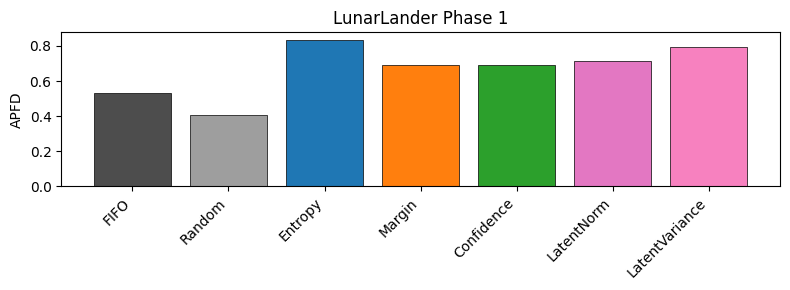

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


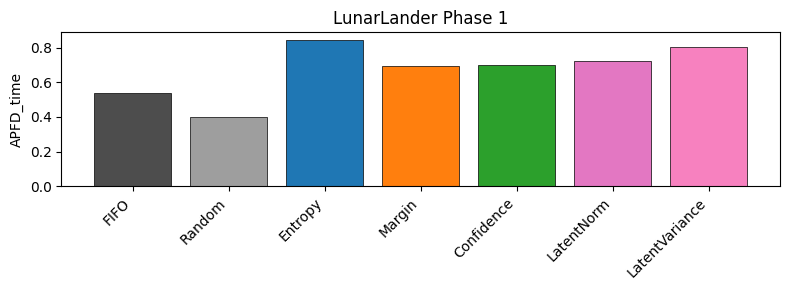

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


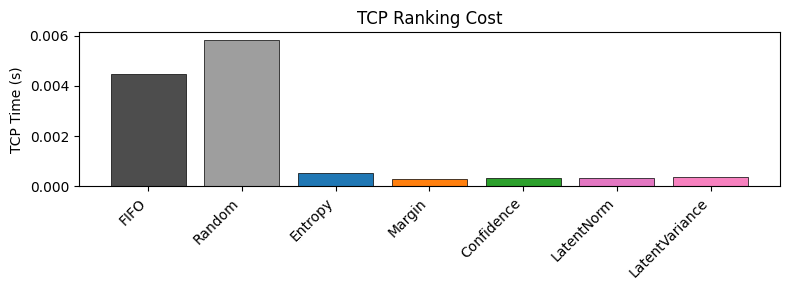

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
def main():

    print("=" * 70)
    print("LUNARLANDER TCP REPLICATION")
    print("=" * 70)

    phase1_results = run_phase1()

    phase1_agg = summarize_phase1(
        phase1_results
    )

    phase1_stats = phase1_statistics(
        phase1_results
    )

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase1_apfd_time(
        phase1_agg
    )

    plot_phase1_overhead(
        phase1_agg
    )

    return {
        "phase1_results":
            phase1_results,

        "phase1_aggregate":
            phase1_agg,

        "phase1_statistics":
            phase1_stats,
    }


outputs = main()